In [56]:
import pandas as pd

# Dias da semana sem sábado
DAYS = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta']
START_HOUR = 7
END_HOUR = 23

# Gera os horários como strings "HH:MM", começando em 07:30
def generate_time_slots(start_hour=START_HOUR, end_hour=END_HOUR):
    times = []
    for hour in range(start_hour, end_hour):
        times.append(f"{hour:02d}:30")
        times.append(f"{hour+1:02d}:00")
    return times

time_slots = generate_time_slots()

# Codificação fornecida: 2=segunda, 3=terça, ..., 6=sexta
def decode_schedule(code):
    day_map = {
        '2': 'Segunda',
        '3': 'Terça',
        '4': 'Quarta',
        '5': 'Quinta',
        '6': 'Sexta'
    }

    try:
        dia_cod = code[0]
        if dia_cod not in day_map:
            return []  # ignora se for sábado ou inválido

        day = day_map[dia_cod]
        hour = int(code[1:3])
        minute = int(code[3]) * 10  # ex: 3 → 30
        duration = int(code[4])     # em horas de aula (1h = 2 blocos de 30min)

        start_time = f"{hour:02d}:{minute:02d}"
        start_index = time_slots.index(start_time)

        return [(day, time_slots[start_index + i]) for i in range(duration * 2)]
    except Exception:
        return []

# Gera a grade de um professor
def build_schedule_for_professor(df, professor_name):
    schedule = pd.DataFrame(0, index=time_slots, columns=DAYS)

    df_prof = df[df["Professor(a)"] == professor_name]
    if df_prof.empty:
        return schedule, True

    for horarios in df_prof["Horario"].dropna():
        for bloco in horarios.split("/"):
            for dia, horario in decode_schedule(bloco.strip()):
                if dia in schedule.columns and horario in schedule.index:
                    schedule.loc[horario, dia] += 1

    return schedule, False


In [57]:
disciplinas = pd.read_csv('/users/moi6/github/ditribuicao/data/disciplinas_2025_1.csv')

In [58]:
grade, vazia = build_schedule_for_professor(disciplinas, 'Carlos Antônio Dornellas')

<Axes: >

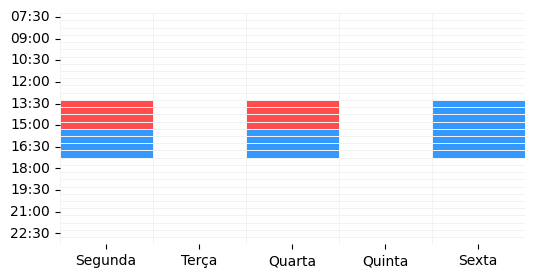

In [59]:
fig, ax = plt.subplots(figsize=(6, 3))
cmap = sns.color_palette(["#ffffff", "#3399ff", "#ff4d4d"])  # branco, azul, vermelho
sns.heatmap(grade, cmap=cmap, cbar=False, linewidths=0.5, linecolor="#f2f2f2", ax=ax)

# ax.set_title(f"Horário semanal de {prof_selecionado}")
# ax.set_xlabel("Horário")
# ax.set_ylabel("Dia da semana")